# Final Project: ECG & Temperature BLE Device

## Battery Voltage Measurement

Verify the accuracy of your battery level measurement (`AIN0`) for 0-3.7 V, as read through the nRF Connect app Bluetooth Battery Level GATT.  Quantitative analysis should include:
  * Linear regression analysis of the input voltage versus the battery level for both the `LOG_INF()` output, the oscilloscope measurement of the PWM duty cycle, and the nRF Connect app.
  * 95% confidence intervals for the slope and intercept of the linear regression.

### Methods

To verify the accuracy of the battery level measurement (only did from 0-3 V), I looked at outputs from LOG_INF(), the oscilloscope measurement of the PWM duty cycle of LED1, and the nRF Connect App. First, I hooked up a power supply to my device (P0.02 and GND). Then, I got the outputs for voltages of 0, 0.5, 1, 1.5, 2, 2.5, and 3 Volts. The oscilloscope measurement was found by finding the time the LED was on/off. The other outputs were through the device LOGGING or sending via bluetooth.

To convert the oscilloscope measurements to battery percentage (brightness), I converted the high time by doing the following equation: (high time) / (high time + low time).

### Results

Battery LED Test - PWM Duty Cycle

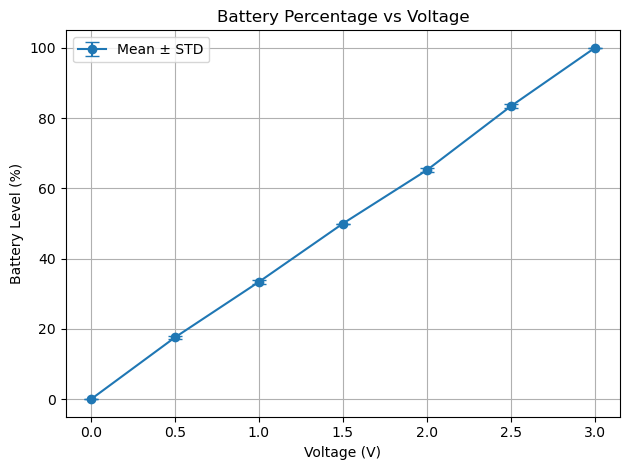

--- Linear Regression Results ---
Slope:     33.1007
Intercept: 0.2921
95% CI for Slope:     [32.39863637 33.80279255]
95% CI for Intercept: [-0.9735893   1.55778925]
R² (vs Ideal): 0.9997


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

file_path = "/Users/arshsingh/Desktop/Spring_2025/BME_554/ecg-temp-ble-project/testing/battery_test.xlsx"
df = pd.read_excel(file_path, header=1, usecols="A:F,K")

df.columns = ['Voltage', 'High T1', 'High T2', 'High T3', 'High T4', 'High T5', 'Low T5']

df_low = pd.read_excel(file_path, header=1, usecols="G:J")
df_low.columns = ['Low T1', 'Low T2', 'Low T3', 'Low T4']


for i in range(1, 5):
    df[f'Low T{i}'] = df_low[f'Low T{i}']

high_trials = [f'High T{i}' for i in range(1, 6)]
low_trials  = [f'Low T{i}' for i in range(1, 6)]

for i in range(5):
    df[f'Battery T{i+1}'] = 100 * df[high_trials[i]] / (df[high_trials[i]] + df[low_trials[i]])

df['Battery Mean'] = df[[f'Battery T{i+1}' for i in range(5)]].mean(axis=1)
df['Battery Std']  = df[[f'Battery T{i+1}' for i in range(5)]].std(axis=1)

plt.errorbar(df['Voltage'], df['Battery Mean'], yerr=df['Battery Std'],
             fmt='o-', capsize=5, label='Mean ± STD')

plt.xlabel("Voltage (V)")
plt.ylabel("Battery Level (%)")
plt.title("Battery Percentage vs Voltage")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

X = sm.add_constant(df['Voltage'])
y = df['Battery Mean']
model = sm.OLS(y, X).fit()

intercept, slope = model.params
conf_int = model.conf_int(alpha=0.05)

ideal = (df['Voltage'] / 3.0) * 100
r_squared = np.corrcoef(df['Battery Mean'], ideal)[0, 1] ** 2

print("--- Linear Regression Results ---")
print(f"Slope:     {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"95% CI for Slope:     {conf_int.loc['Voltage'].values}")
print(f"95% CI for Intercept: {conf_int.loc['const'].values}")
print(f"R² (vs Ideal): {r_squared:.4f}")


Battery Level Test


--- Battery Test (High/Low) Linear Regression ---
Slope:     33.1007
Intercept: 0.2921
95% CI for Slope:     [32.39863637 33.80279255]
95% CI for Intercept: [-0.9735893   1.55778925]
R² (vs Ideal): 0.9997

--- LOG_INF Output (%) Linear Regression ---
Slope:     33.3514
Intercept: -0.0700
95% CI for Slope:     [33.11734685 33.58551029]
95% CI for Intercept: [-0.49199682  0.35199682]
R² (vs Ideal): 1.0000

--- Bluetooth Output (%) Linear Regression ---
Slope:     33.2857
Intercept: 0.0429
95% CI for Slope:     [32.92143796 33.64999061]
95% CI for Intercept: [-0.61385134  0.69956562]
R² (vs Ideal): 0.9999


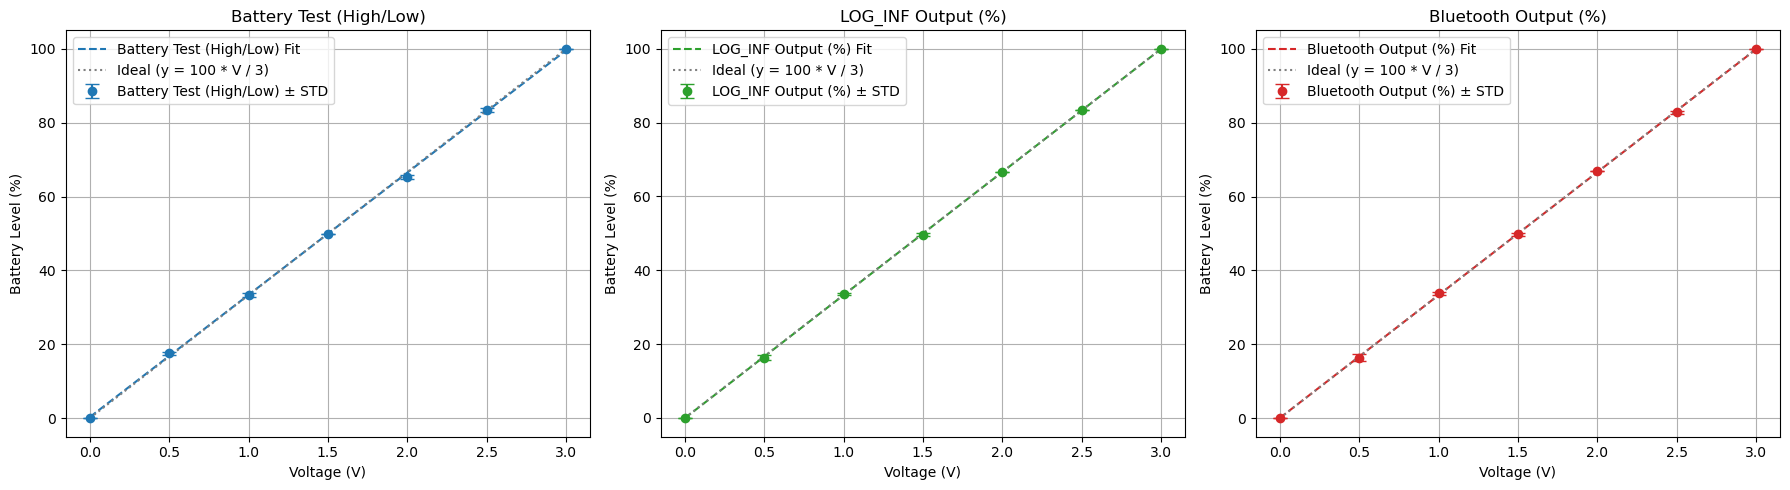

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

file1_path = "battery_test.xlsx"
df1 = pd.read_excel(file1_path, header=1, usecols="A:F,K")
df1.columns = ['Voltage', 'High T1', 'High T2', 'High T3', 'High T4', 'High T5', 'Low T5']
df1_low = pd.read_excel(file1_path, header=1, usecols="G:J")
df1_low.columns = ['Low T1', 'Low T2', 'Low T3', 'Low T4']
for i in range(1, 5):
    df1[f'Low T{i}'] = df1_low[f'Low T{i}']
high_trials = [f'High T{i}' for i in range(1, 6)]
low_trials  = [f'Low T{i}' for i in range(1, 6)]
for i in range(5):
    df1[f'Battery T{i+1}'] = 100 * df1[high_trials[i]] / (df1[high_trials[i]] + df1[low_trials[i]])
df1['Battery Mean'] = df1[[f'Battery T{i+1}' for i in range(5)]].mean(axis=1)
df1['Battery Std']  = df1[[f'Battery T{i+1}' for i in range(5)]].std(axis=1)

file2_path = "battery_level_test.xlsx"
df2 = pd.read_excel(file2_path, header=2, usecols="A:L")

df2.drop(df2.columns[6], axis=1, inplace=True)

df2.columns = ['Voltage'] + [f'LOG_INF T{i}' for i in range(1, 6)] + [f'BT T{i}' for i in range(1, 6)]

df2['LOG_INF Mean'] = df2[[f'LOG_INF T{i}' for i in range(1, 6)]].mean(axis=1)
df2['LOG_INF Std']  = df2[[f'LOG_INF T{i}' for i in range(1, 6)]].std(axis=1)
df2['BT Mean']      = df2[[f'BT T{i}' for i in range(1, 6)]].mean(axis=1)
df2['BT Std']       = df2[[f'BT T{i}' for i in range(1, 6)]].std(axis=1)

def plot_and_regress(ax, x, y, yerr, label, color):
    ax.errorbar(x, y, yerr=yerr, fmt='o', capsize=5, label=f'{label} ± STD', color=color)
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    ax.plot(x, model.predict(X), '--', label=f'{label} Fit', color=color)

    ideal = (x / 3.0) * 100
    ax.plot(x, ideal, ':', label='Ideal (y = 100 * V / 3)', color='gray')

    ax.set_xlabel("Voltage (V)")
    ax.set_ylabel("Battery Level (%)")
    ax.set_title(label)
    ax.grid(True)
    ax.legend()
    
    intercept, slope = model.params
    conf_int = model.conf_int(alpha=0.05)
    r_squared = np.corrcoef(y, ideal)[0, 1] ** 2
    print(f"\n--- {label} Linear Regression ---")
    print(f"Slope:     {slope:.4f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"95% CI for Slope:     {conf_int.loc['Voltage'].values}")
    print(f"95% CI for Intercept: {conf_int.loc['const'].values}")
    print(f"R² (vs Ideal): {r_squared:.4f}")


fig, axs = plt.subplots(1, 3, figsize=(18, 5))

plot_and_regress(axs[0], df1['Voltage'], df1['Battery Mean'], df1['Battery Std'], label="Battery Test (High/Low)", color='tab:blue')
plot_and_regress(axs[1], df2['Voltage'], df2['LOG_INF Mean'], df2['LOG_INF Std'], label="LOG_INF Output (%)", color='tab:green')
plot_and_regress(axs[2], df2['Voltage'], df2['BT Mean'], df2['BT Std'], label="Bluetooth Output (%)", color='tab:red')

plt.tight_layout()
plt.show()


### Discussion

Each output type—oscilloscope, LOG_INF, and Bluetooth—exhibits a strong linear relationship between voltage and battery level, as expected. This is backed by R^2 values that are either 1 or, essentially, close to 1. Among them, the oscilloscope provides the most accurate representation of battery percentage, as it directly reflects the actual LED brightness, which is proportional to duty cycle. In contrast, the LOG_INF output reports only the computed percentage, and the Bluetooth output is less precise due to rounding to the nearest integer.

## ECG Heart Rate Measurement
Demonstrate that your average heart rate measurement is accurate, as recorded through `LOG_INF()` output, the oscilloscope measurements, and the nRF Connect app, relative to what was set on the function generator.  This should be done for 40, 60, 120, 150, and 180 bpm.  The 25% duty cycle should also be verified. Quantitative analysis should include:
  * Linear regression analysis of the recorded heart rate versus the set heart rate for both the `LOG_INF()` output, oscilloscope measurements, and the nRF Connect app.
  * 95% confidence intervals for the slope and intercept of the linear regression.
  * Verification that the duty cycle of out output is 25% for all heart rates.

### Methods

The average heart rate measurement is calcuated by finding the number of peaks and dividing over the time (scaled to minute) for the LOG_INF() and nRF Connect App outputs. For the oscilloscope measurements, the average heart rate is found by calculating the R-R interval.

Heart rate measurements were found for 40, 60, 120, 150, and 180 BPM - five trials each. 

The 25% duty cycle is found using the oscilloscope to calculate the on/off times for the LED.

### Results

Recorded Heart Rate vs Set Heart Rate

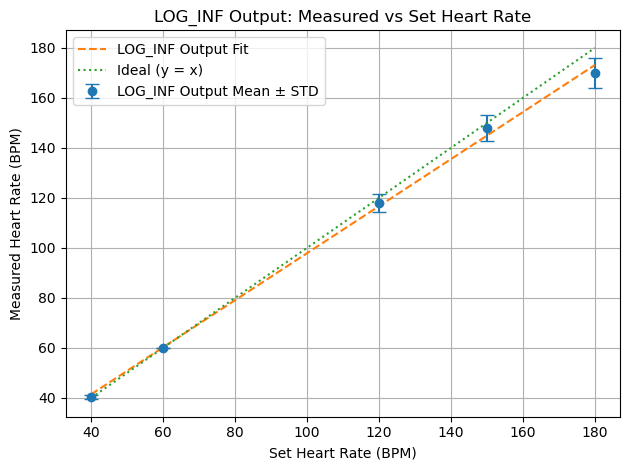


--- LOG_INF Output Linear Regression ---
Slope: 0.9409
Intercept: 3.7857
95% CI for Slope: [0.8676943  1.01401999]
95% CI for Intercept: [-5.14494873 12.71637731]
R² (vs Ideal): 0.9982


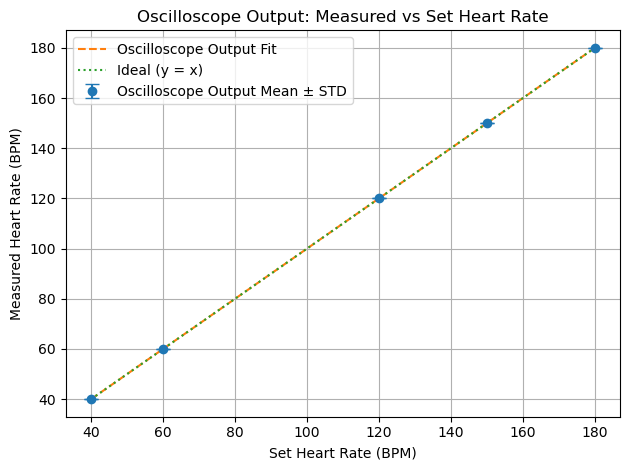


--- Oscilloscope Output Linear Regression ---
Slope: 1.0000
Intercept: 0.0000
95% CI for Slope: [1. 1.]
95% CI for Intercept: [-1.06263460e-13  1.63106879e-13]
R² (vs Ideal): 1.0000


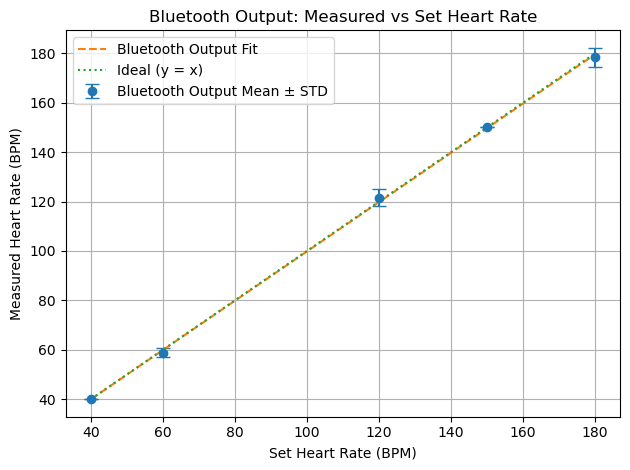


--- Bluetooth Output Linear Regression ---
Slope: 0.9974
Intercept: 0.0429
95% CI for Slope: [0.9588265  1.03603064]
95% CI for Intercept: [-4.66912604  4.75484033]
R² (vs Ideal): 0.9996


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

file_path = "heart_rate_test.xlsx"
df = pd.read_excel(file_path, skiprows=1)

df.columns = [
    "Set BPM", 
    "LOG_INF T1", "LOG_INF T2", "LOG_INF T3", "LOG_INF T4", "LOG_INF T5",
    "blank", 
    "Scope T1", "Scope T2", "Scope T3", "Scope T4", "Scope T5",
    "blank",
    "Bluetooth T1", "Bluetooth T2", "Bluetooth T3", "Bluetooth T4", "Bluetooth T5"
]

df = df.drop(columns=["blank"])

df['LOG_INF Mean'] = df[[f"LOG_INF T{i}" for i in range(1, 6)]].mean(axis=1)
df['LOG_INF Std']  = df[[f"LOG_INF T{i}" for i in range(1, 6)]].std(axis=1)

df['Scope Mean']   = df[[f"Scope T{i}" for i in range(1, 6)]].mean(axis=1)
df['Scope Std']    = df[[f"Scope T{i}" for i in range(1, 6)]].std(axis=1)

df['Bluetooth Mean'] = df[[f"Bluetooth T{i}" for i in range(1, 6)]].mean(axis=1)
df['Bluetooth Std']  = df[[f"Bluetooth T{i}" for i in range(1, 6)]].std(axis=1)

def run_regression(x, y, y_std, label):
    plt.errorbar(x, y, yerr=y_std, fmt='o', capsize=5, label=f'{label} Mean ± STD')
    
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    intercept, slope = model.params
    conf_int = model.conf_int(alpha=0.05)

    ideal = x
    r_squared = np.corrcoef(y, ideal)[0, 1] ** 2

    plt.plot(x, model.predict(X), '--', label=f'{label} Fit')
    plt.plot(x, ideal, ':', label='Ideal (y = x)')

    plt.xlabel("Set Heart Rate (BPM)")
    plt.ylabel("Measured Heart Rate (BPM)")
    plt.title(f"{label}: Measured vs Set Heart Rate")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n--- {label} Linear Regression ---")
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"95% CI for Slope: {conf_int.loc['Set BPM'].values}")
    print(f"95% CI for Intercept: {conf_int.loc['const'].values}")
    print(f"R² (vs Ideal): {r_squared:.4f}")

run_regression(df['Set BPM'], df['LOG_INF Mean'], df['LOG_INF Std'], label="LOG_INF Output")
run_regression(df['Set BPM'], df['Scope Mean'], df['Scope Std'], label="Oscilloscope Output")
run_regression(df['Set BPM'], df['Bluetooth Mean'], df['Bluetooth Std'], label="Bluetooth Output")


25% Duty Cycle

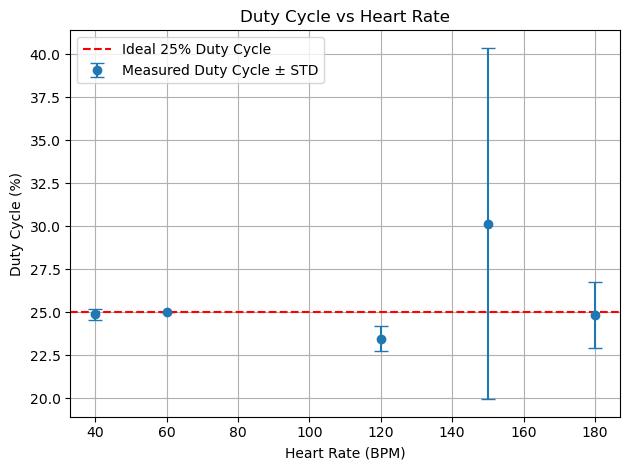

--- Duty Cycle Verification ---
40 BPM: Mean = 24.89% ± 0.32%
60 BPM: Mean = 25.00% ± 0.00%
120 BPM: Mean = 23.47% ± 0.74%
150 BPM: Mean = 30.17% ± 10.21%
180 BPM: Mean = 24.83% ± 1.92%


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "25_percent_duty_cycle_test.xlsx"
df = pd.read_excel(file_path, header=1)

df.columns = [
    "Heart Rate", "High T1", "High T2", "High T3", "High T4", "High T5",
    "blank", "Low T1", "Low T2", "Low T3", "Low T4", "Low T5"
]
df = df.drop(columns=["blank"])

df = df.apply(pd.to_numeric, errors="coerce")

high_cols = [col for col in df.columns if "High" in col]
low_cols  = [col for col in df.columns if "Low" in col]

duty_cycles = pd.DataFrame()
for h_col, l_col in zip(high_cols, low_cols):
    duty_cycles[h_col.replace("High", "Duty")] = (
        df[h_col] / (df[h_col] + df[l_col]) * 100
    )

df["Duty Mean"] = duty_cycles.mean(axis=1)
df["Duty Std"]  = duty_cycles.std(axis=1)

plt.errorbar(
    df["Heart Rate"], df["Duty Mean"], yerr=df["Duty Std"],
    fmt="o", capsize=5, label="Measured Duty Cycle ± STD"
)
plt.axhline(25, color="r", linestyle="--", label="Ideal 25% Duty Cycle")
plt.xlabel("Heart Rate (BPM)")
plt.ylabel("Duty Cycle (%)")
plt.title("Duty Cycle vs Heart Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("--- Duty Cycle Verification ---")
for idx, row in df.iterrows():
    print(f"{int(row['Heart Rate'])} BPM: Mean = {row['Duty Mean']:.2f}% ± {row['Duty Std']:.2f}%")


### Discussion

The oscilloscope output aligned precisely with the expected heart rate values, confirming that the inputted heart rate was accurately reflected in the signal. Since the initial LOG_INF and Bluetooth outputs yielded identical results, I used this opportunity to perform additional trials after modifying the heartbeat peak detection threshold.

For the LOG_INF output, a higher threshold was used, which introduced greater variability in the measured heart rate, deviating more from the expected values. This is reflected in a lower coefficient of determination (R² ≈ 0.94). Conversely, the Bluetooth output was tested using a lower threshold, and the results exhibited improved accuracy with significantly reduced variability, yielding a much higher R² of 0.9996.

In the context of 25% duty cycle verification, increased variability was observed as the heart rate increased. This trend is consistent with expectations, as higher heart rates challenge the system’s ability to perform rapid and reliable measurements, likely due to sampling limitations and signal processing delays.

## Temperature Sensor Measurment

Demonstrate that your temperature sensor can have a room temperature measurement read through `LOG_INF()` output and the nRF Connect app.  Do this in 3 locations with different temperatures.  You do not need to verify accuracy, just a reasonable measurements with agreement.

### Methods

To measure the temperature, the outputs from LOG_INF and nRF Connect App were observed after running the measure functionality in three different rooms - the Lab, my apartment in Swift, and Fitzpatrick fish bowl room. 

### Results

#### Room Temperature Measurements

LOG_INF output
1) Lab Temperature - 24 degrees Celsius
2) Apartment Temperature - 23.5 degrees Celsius
3) Fitzpatrick Temperature - 24.5 degrees Celsius

nRF Connect App
1) Lab Temperature - 24 degrees Celsius
2) Apartment Temperature - 23.575 degrees Celsius
3) Fitzpatrick Temperature - 24.5 degrees Celsius

### Discussion

The temperatures recorded from the device are pretty reasonable for what we expect.